# SDA 2026: Homework notebook 1

- Please put your solutions into this notebook
- Submit the notebook before **Wednesday 15 April 2026 17:00**
- This is an individual assignment.

**What is expected:**
- Clear and readable code (e.g. meaningful variable names).
- Use comments in your code to explain what you are doing.
- Add labels to the axes of your figures, including units if applicable, with readable font sizes.
- Add a legend to a figure with `plt.legend()` by setting the `label` argument in `plt.plot()`.
- Use `print()` statements to give the answers to questions that don't require a figure.
- Avoid loops if vectorized operations are possible.
- Use [formatted strings](https://www.w3schools.com/python/python_string_formatting.asp) to control the number of significant digits in your print statements.

In [1]:
# You can use this cell to define any general settings
import matplotlib.pyplot as plt
import numpy as np

# If this astropy import fails
# you have to install astropy (within anaconda or using pip)
# ask a TA for help if needed
from astropy.io import ascii

# Optional: set a random seed for reproducibility
np.random.seed(42)

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## 1. Home-grown Gaussian sampler (12 points)

In the reading material for week 1 and during the lecture you learned about the cumulative probability distribution (CDF). In this exercise you learn how to use the CDF to obtain samples from _any_ probability density function (PDF). We use the Gaussian distribution as an example.

The Gaussian PDF is defined mathematically as:

$$
p(x) = \frac{1}{\sqrt{ 2 \pi \sigma^2 }} e^{ - \frac{ (x - \mu)^2 } {2 \sigma^2} }
$$

**Question 1.1** (1 point): Plot the Gaussian PDF for `mu=1` and `sigma=1.2`, use 100 points along the direction of $x$ in the range $-5$ and $+5$. Before creating the plot, write a function to calculate the Gaussian PDF for a given input array of $x$.

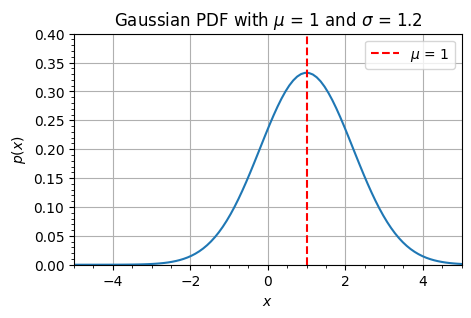

In [2]:
from turtle import color
from math import ceil

def gaussian_pdf(x, mu, sigma):
    """
    Return Gaussian PDF evaluated at x.
    """

    return 1 / np.sqrt(2 * np.pi * sigma**2) * np.exp(-1 * (x - mu) ** 2 / (2 * sigma**2))

mu, sigma = 1, 1.2
x = np.linspace(-5, 5, 100)
pdf = gaussian_pdf(x, mu, sigma)
plt.plot(x, pdf)
plt.xlabel(r"$x$")
plt.ylabel(r"$p(x)$")
plt.title(r"Gaussian PDF with $\mu$ = " + str(mu) + r" and $\sigma$ = " + str(sigma))
plt.ylim(0, ceil((max(pdf) * 1.1)*10)/10)
plt.xlim(-5, 5)
plt.axvline(mu, color="red", linestyle="--", label=r"$\mu$ = " + str(mu))
plt.legend()
plt.grid()
plt.show()

**Question 1.2** (2 point): From the result of Q1.1, create and plot the CDF over the same range of points in the x-direction. *Tip: use `np.trapezoid()` or `np.cumsum()` for calculating the integral*. Via interpolation, estimate the value of $x$ when your CDF is equal to $0.5$. Comment on the result (do you get the expected answer)?  

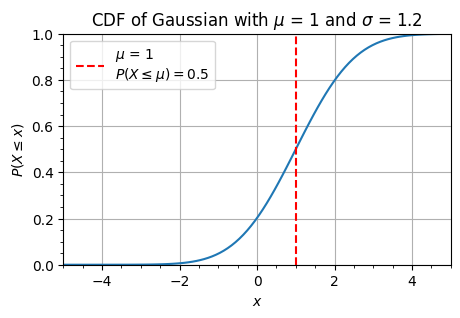

In [ ]:
cdf = [np.trapezoid(pdf[0:i], x[0:i]) for i in range(1, len(x) + 1)] # sums up the area under the curve of the PDF to get the CDF
plt.plot(x, cdf)
plt.xlabel(r"$x$")
plt.ylabel(r"$P(X \leq x)$")
plt.title(r"CDF of Gaussian with $\mu$ = " + str(mu) + r" and $\sigma$ = " + str(sigma))
plt.ylim(0, 1)
plt.xlim(-5, 5)
plt.axvline(mu, color="red", linestyle="--", label=r"$\mu$ = " + str(mu) + '\n' + r"$P(X \leq \mu) = 0.5$")
plt.legend()
plt.grid()
plt.show()

Now comes the important part: you will find out how to draw samples for the CDF.

The trick is to realize that the tails of the PDF correspond to values very close to 0 and 1 in the CDF. If we draw from samples from a uniform distribution in the interval $[0,1]$, the mean will be at $0.5$, and we are unlikely to obtain values very close to $0$ or $1$.

Using the steps below, you will demonstrate that samples from a uniform distribution can be used to reconstruct the PDF from the CDF.

**Question 1.3** (0.5 points): Draw $1000$ random samples from a uniform distribution in the interval $[0,1]$, which we will call `uni_arr` (*tip: if needed, check out the notebook on random numbers, which you can find on Brightspace*).

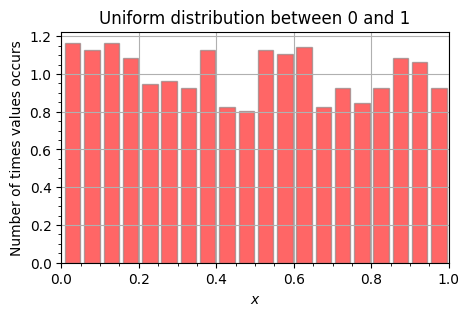

In [ ]:
uni_arr = np.random.uniform(0, 1, 1000) # creates a uniform distribution
plt.hist(uni_arr, bins=20, density=True, alpha=0.6, color="r", edgecolor="gray", rwidth=0.8)
plt.xlabel(r"$x$")
plt.ylabel(r"Number of times values occurs")
plt.title(r"Uniform distribution between 0 and 1")
plt.xlim(0, 1)
plt.grid()
plt.show()

**Question 1.4** (0.5 points): Let's pick one number in your array of uniform samples, say the 5th one. Find the $x$ value for which your CDF is equal to this random number. In other words, find $x$ for which `CDF(x) == uni_arr[4]`. The answer should be only one line of code.

In [ ]:
x_min = np.argmin(np.abs(cdf - uni_arr[4])) # finds the index of the minimum difference between the CDF and the random value
print(f"The value of x for which the CDF is closest to the 5th value in uni_arr is: {x[x_min]:.3f}\nThis corresponds to P(X ≤ x) = {cdf[x_min]:.3f}")

The value of x for which the CDF is closest to the 5th value in uni_arr is: -0.253
This corresponds to P(X ≤ x) = 0.148


**Question 1.5** (1 point): Now find the $x$ value of CDF for each of the $1000$ uniform samples. Plot the resulting distribution in a histogram, using `density=True` to normalize your histogram. Does this look familiar? If so, overplot the analytical function that describes this histogram. Remember to use `label='...'` and `plt.legend()` to explain what you are plotting.

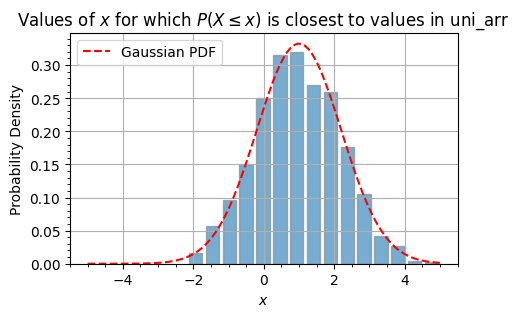

In [6]:
x_vals = [x[np.argmin(np.abs(cdf - uni_arr[i]))] for i in range(len(uni_arr))]
plt.hist(x_vals, bins=15, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8)
plt.xlabel(r"$x$")
plt.ylabel("Probability Density")
plt.title(r"Values of $x$ for which $P(X \leq x)$ is closest to values in uni_arr")
plt.plot(x, pdf, color="red", label="Gaussian PDF", linestyle='--')
plt.legend() # Did not add a label to histogram due to size
plt.grid()
plt.show()

In this exercise we have of course reinvented the wheel. As you might already know, NumPy has a built-in sampler for the Gaussian PDF, `np.random.normal()`. However in the future you will likely encounter a PDF that has no analytical form, and in this case you can always follow the steps above to obtain samples from your PDF.

Being able to sample from the PDF can very helpful (for example, for error propagation). Let's do one last computation. For these questions you can use `np.random.normal` to obtain your samples.

By integrating the Gaussian distribution we can find the probability to find a value between  $\mu \pm 2\sigma$ is [95.45%](https://en.wikipedia.org/wiki/68–95–99.7_rule).

**Question 1.6** (2 points): We do a Monte Carlo simulation by drawing $100$ samples from a Gaussian distribution, for which you can choose $\mu$ and $\sigma$ yourself. Find the fraction of samples that are contained with $\mu \pm 2\sigma$. Please report your answer to three significant digits and report the result five times, each time redrawing $100$ Gaussian samples.

In [ ]:
mu, sigma = 1, 1.2
N = 100 # number of samples to draw from the Gaussian distribution
percentages = []
for tries in range(5):
    samples = np.random.normal(mu, sigma, N)

    # redundant code for plotting the histogram of the samples, looked messy so commented out
    # plt.hist(samples, bins=20, alpha=0.6, edgecolor="gray", rwidth=0.8)
    # plt.xlabel(r"$x$")
    # plt.ylabel(r"Number of times values occurs")
    # plt.title(r"Histogram of " + str(N) + r" samples drawn from Gaussian with $\mu$ = " + str(mu) + r" and $\sigma$ = " + str(sigma))
    # plt.xlim(-5, 5)
    # plt.grid()
    # plt.show()

    contained = np.sum((samples >= (mu - 2 * sigma)) & (samples <= (mu + 2 *sigma)))
    percentage = (contained/N)*100
    percentages.append(percentage)
    print(f"Number of samples within 2σ of the mean: {contained} out of {N} samples, which is {percentage:.1f}%") 
print(f'The mean percentage is: {np.mean(percentages):.1f}%')

Number of samples within 2σ of the mean: 97 out of 100 samples, which is 97.0%
Number of samples within 2σ of the mean: 96 out of 100 samples, which is 96.0%
Number of samples within 2σ of the mean: 96 out of 100 samples, which is 96.0%
Number of samples within 2σ of the mean: 91 out of 100 samples, which is 91.0%
Number of samples within 2σ of the mean: 96 out of 100 samples, which is 96.0%
The mean percentage is: 95.2%


**Question 1.7** (1 point): You will find similar but somewhat different answers for the five Monte Carlo simulations of Q1.6. Explain why this happens. Is it ever possible for this difference to be exactly zero? Why (not)?

In [ ]:
print('The small changes in between the different ismulations are due to the random nature of sampling. \nIf we were to increase the number of samples drawn, we would expect the percentage to converge towards the theoretical value of approximately 95.4% for a Gaussian distribution. \nThis is due to the need of there only being one extra "outlier" sample to cause the percentage to diverge away from the real value. \nIt is therefore possible for the exact difference to be exactly 0, as it is not unheard of to have a single outlier.')


The small changes in between the different ismulations are due to the random nature of sampling. 
If we were to increase the number of samples drawn, we would expect the percentage to converge towards the theoretical value of approximately 95.4% for a Gaussian distribution. 
This is due to the need of there only being one extra "outlier" sample to cause the percentage to diverge away from the real value. 
It is therefore possible for the exact difference to be exactly 0, as it is not unheard of to have a single outlier.


In the reading material of week 1 you have seen the mathematical derivation that the uncertainty on the mean of a distribution scales with $1/\sqrt{N}$, with $N$ the number of samples that are used to compute the mean. We can also demonstrate this scaling using simulated data.

**Question 1.8** (2 points): Draw $20$ samples from a normal distribution with $\mu=5$ and $\sigma=3$, and compute the mean of this simulated data, $\bar{x}$. Now repeat this step $500$ times and make a histogram of the $500$ $\bar{x}$'s that you create. What is the sample variance, $\sigma_n^2$, of this distribution of $\bar{x}$? Show that this sample variance is consistent with the theoretical expectation. Show in your plot that the distribution of $\bar{x}$ follows a Gaussian distribution.

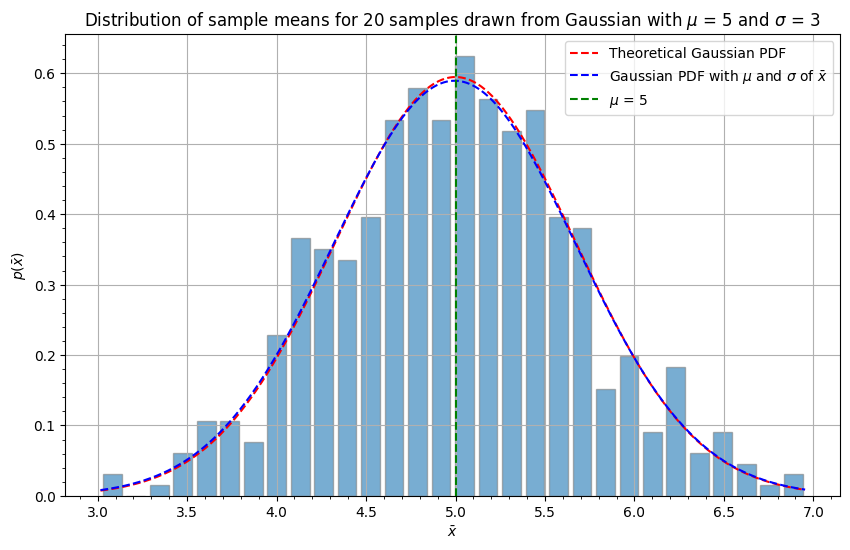

We found that the mean of x_mean is 4.99 and the variance of x_mean is 0.46. 
The theoretical mean of x_mean is equal to the mean of the original distribution, which is 5, and the theoretical standard deviation of x_mean is equal to the standard deviation of the original distribution divided by the square root of N, which is 0.67. 
The results from our simulation are consistent with these theoretical values.


In [ ]:
mu, sigma = 5, 3
N = 20
x_means = []
N_sims = 500

# Calculates the mean of N samples and creates a list of these means for N_sims simulations
for _ in range(N_sims):
    x_samples = np.random.normal(mu, sigma, N)
    x_means.append(np.mean(x_samples))

# Creates lists needed for plot
x_vals = np.linspace(min(x_means), max(x_means), 1000)
y = gaussian_pdf(x_vals, mu, sigma/np.sqrt(N))
y_test = gaussian_pdf(x_vals, np.mean(x_means), np.std(x_means))

# Creates the plot
plt.figure(figsize=(10, 6))
plt.hist(x_means, bins=30, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8)
plt.plot(x_vals, y, color="red", label="Theoretical Gaussian PDF", linestyle='--')
plt.plot(x_vals, y_test, color="blue", label=r"Gaussian PDF with $\mu$ and $\sigma$ of $\bar{x}$", linestyle='--')
plt.xlabel(r"$\bar{x}$")
plt.ylabel(r"$p(\bar{x})$")
plt.axvline(mu, color="green", linestyle="--", label=r"$\mu$ = " + str(mu))
plt.title(r"Distribution of sample means for " + str(N) + r" samples drawn from Gaussian with $\mu$ = " + str(mu) + r" and $\sigma$ = " + str(sigma))
plt.legend()
plt.grid()
plt.show()
print(f'We found that the mean of x_mean is {np.mean(x_means):.2f} and the variance of x_mean is {np.var(x_means):.2f}. \nThe theoretical mean of x_mean is equal to the mean of the original distribution, which is {mu}, and the theoretical standard deviation of x_mean is equal to the standard deviation of the original distribution divided by the square root of N, which is {sigma/np.sqrt(N):.2f}. \nThe results from our simulation are consistent with these theoretical values.')

**Question 1.9** (2 points): Finally, repeat the steps of Q1.8, each time increasing the number of samples, $N$, that are used to compute the mean. Demonstrate that the uncertainty on the mean decreases with $\sqrt{N}$.

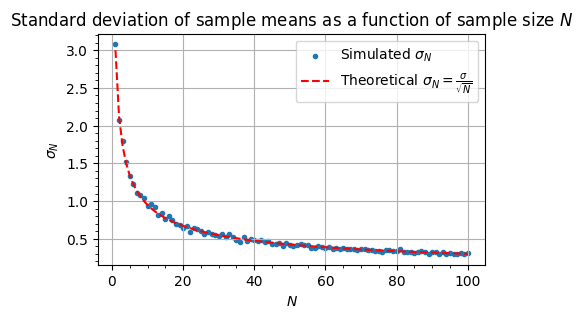

In [ ]:
N_range = np.arange(1, 101)
N_std = []

# For each N, calculates the uncertainty of the mean
for N in N_range:
    x_means = []
    for _ in range(N_sims):
        x_samples = np.random.normal(mu, sigma, N)
        x_means.append(np.mean(x_samples))
    N_std.append(np.std(x_means))

# plots the data
plt.scatter(N_range, N_std, label=r"Simulated $\sigma_N$", marker = '.')
plt.plot(N_range, sigma/np.sqrt(N_range), color="red", label=r"Theoretical $\sigma_N = \frac{\sigma}{\sqrt{N}}$", linestyle='--')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sigma_N$")
plt.title(r"Standard deviation of sample means as a function of sample size $N$")
plt.legend()
plt.grid()
plt.show()

## 2. Kolmogorov-Smirnov meets Anderson-Darling (10 points)

We can use the CDF to measure the difference of an observable of two different populations. In general, we want to test the *null hypothesis* that the two distributions are drawn from the same underlying distribution. One way we can do this is by measuring the difference between the CDF of the two distributions we want to investigate. This measurement of the difference between two CDFs is called a a *test statistic* computed from the two samples. We then compute the probability of obtaining a test statistic at least this extreme if the null hypothesis is true. This probability is called the *p-value*. If the *p-value* is low, we can reject the null hypothesis.

How low the p-value should be before we call a result significant is a choice we have to make. In general, $p<0.01$ is a good boundary.

How we construct our measurement of the statistic is another choice we have to make. The classical approach to obtain a statistic of the CDF is the Kolmogorov-Smirnov (KS) test, which is based on the maximum difference between two CDFs. The Anderson-Darling (AD) test also compares the CDFs, but gives relatively more weight to differences in the tails of the distributions.

You will not have to write your own algorithm of the KS or AD test. Instead, in this exercise we will apply the `scipy` implementation of these tests and confirm that they work.

We will work with *real* astronomical data: a population of supernovae (SNe) and Gamma-ray bursts (GRBs). The observables are the redshift, $z$, and the fraction of galaxy light enclosed with the location of the SN or GRB, $F_{\rm light}$. More background information is in the lecture slides of week 2.

We use the data from the famous paper by [Fruchter et al. (2006)](https://ui.adsabs.harvard.edu/abs/2006Natur.441..463F). The data are copied below. Run this cell to read the data into an astropy `Table` object. If you have not worked with `Table` data before, it would be good to read some [documentation](https://docs.astropy.org/en/stable/table/).

In [11]:
grb_data_str = """
GRB INST Mag z MV r80kpc F_light Perr
970228 STIS 25.88 0.685 -17.26 3.2 - 0.025
970508 STIS 25.19 0.84 -17.92 1.48 100 0.007
970828 WFPC2 24.43 0.958 -18.93 2.8 - -
971214 STIS 26.35 3.42 -20.49 2.36 53.5 0.150
980326 STIS 29.73 1 -13.85 - 100 0.033
980425 GROUND 15.19 0.0085 -17.59 - - -
980613 STIS 25.33 1.10 -18.48 3.75 41.6 0.075
980703 STIS 22.91 0.97 -20.55 2.42 55.7 0.035
990123 STIS 24.41 1.60 -20.07 5.01 11.3 0.005
990506 STIS 25.53 1.30 -18.56 1.53 - -
990510 STIS 28.20 1.62 -16.75 1.75 79.4 0.006
990705 STIS 22.78 0.86 -20.47 9.38 - 0.028
990712 STIS 22.45 0.43 -19.12 2.25 97.1 0.012
991208 STIS 24.60 0.71 -18.05 1.16 94.0 0.073
991216 STIS 26.79 1.02 -18.40 2.25 82.5 0.030
000131 WFPC2 24.86 4.50 -21.50 5.93 49.1 0.100
000210 GROUND 24.22 0.85 -18.83 - - -
000301 STIS 28.90 2.03 -16.07 1.00 51.2 0.006
000418 STIS 24.15 1.12 -19.55 1.70 45.4 0.150
000911 GROUND - 1.06 -18.95 - - -
000926 WFPC2 24.18 2.04 -20.73 10.25 100 0.013
010222 WFPC2 25.61 1.47 -18.62 2.87 92.7 0.013
010921 WFPC2 22.58 0.45 -19.41 2.76 43.9 0.015
011121 WFPC2 23.23 0.36 -19.41 5.89 51.1 0.016
011211 STIS 25.97 2.12 -19.05 2.69 95.3 0.006
020405 WFPC2 21.59 0.69 -21.11 11.96 58.7 0.010
020813 ACS 24.46 1.25 -19.69 2.13 88.0 0.008
020819 GROUND 19.48 0.41 -21.88 - - -
020903 ACS 21.63 0.25 -18.98 1.43 95.8 0.006
021004 ACS 24.63 2.33 -20.63 1.81 100 0.006
021211 ACS 25.43 1.02 -18.05 1.63 75.8 0.007
030115 ACS 25.58 2.5 - - 86.3 0.060
030323 ACS 27.28 3.37 -18.53 1.86 86.2 0.060
030329 ACS 23.07 0.17 -16.37 1.03 99.1 0.006
031203 GROUND - 0.105 -20.73 - - -
040924 ACS 23.93 0.859 -19.21 3.234 - 0.013
041006 ACS 25.15 0.716 -17.53 5.19 - 0.008
"""

In [12]:
sn_data_str = """
SNe Mag z MV r80_kpc F_light
2002fz 22.34 0.84 -20.64 11.70 59.2
2002hq 20.93 0.67 -21.54 16.60 37.1
2002hs 23.25 0.90 -19.87 12.75 9.3
2002kb 20.54 0.58 -21.61 15.82 83.7
2002ke 21.05 0.58 -21.10 18.17 44.2
2002kl 22.54 0.41 -18.82 5.91 13.6
2003N 24.61 0.43 -17.09 3.73 69.1
2003ba 19.92 0.29 -20.65 8.181 81.6
2003bb 21.53 0.95 -21.72 20.37 17.8
2003bc 21.77 0.51 -20.09 4.450 19.9
2003dx 23.26 0.46 -18.36 2.167 44.9
2003dz 25.67 0.48 -16.18 2.47 61.0
2003ea 24.01 0.89 -19.42 4.38 56.7
2003er 21.24 0.63 -19.70 7.16 8.4
2003et 22.98 0.83 -19.79 4.97 85.9
2003ew 21.97 0.66 -20.10 15.21 71.4
"""

Some entries in the table are missing and are marked with `-`. In the next cell we replace these with `0` and then remove rows with missing values in the quantities we need.

In [13]:
# Deal with empty columns
fv =[('-',0, 'F_light'), ('-',0, 'z')]

# Read
grb_data0 = ascii.read(grb_data_str, fill_values=fv)
sn_data0 = ascii.read(sn_data_str, fill_values=fv)

# Remove empty rows
grb_data = grb_data0[(grb_data0['F_light'] > 0) & (grb_data0['z'] > 0)]
sn_data = sn_data0[(sn_data0['F_light'] > 0) & (sn_data0['z'] > 0)]

# Print to check that it worked
print ('GRB data:\n', grb_data)
print ('\nSN data:\n', sn_data)

GRB data:
  GRB    INST  Mag   z     MV   r80kpc F_light  Perr
------ ----- ----- ---- ------ ------ ------- -----
970508  STIS 25.19 0.84 -17.92   1.48   100.0 0.007
971214  STIS 26.35 3.42 -20.49   2.36    53.5 0.150
980326  STIS 29.73  1.0 -13.85      -   100.0 0.033
980613  STIS 25.33  1.1 -18.48   3.75    41.6 0.075
980703  STIS 22.91 0.97 -20.55   2.42    55.7 0.035
990123  STIS 24.41  1.6 -20.07   5.01    11.3 0.005
990510  STIS 28.20 1.62 -16.75   1.75    79.4 0.006
990712  STIS 22.45 0.43 -19.12   2.25    97.1 0.012
991208  STIS 24.60 0.71 -18.05   1.16    94.0 0.073
991216  STIS 26.79 1.02 -18.40   2.25    82.5 0.030
   ...   ...   ...  ...    ...    ...     ...   ...
 11121 WFPC2 23.23 0.36 -19.41   5.89    51.1 0.016
 11211  STIS 25.97 2.12 -19.05   2.69    95.3 0.006
 20405 WFPC2 21.59 0.69 -21.11  11.96    58.7 0.010
 20813   ACS 24.46 1.25 -19.69   2.13    88.0 0.008
 20903   ACS 21.63 0.25 -18.98   1.43    95.8 0.006
 21004   ACS 24.63 2.33 -20.63   1.81   100.0 0.006
 

**Question 2.1** (2 points): Make a plot of the cumulative distribution of the `F_light` observable of the SN and GRB population. Look at Figure 3 of the Fruchter et al. article, you don't have to use any arrows, just plot the CDFs using a line.

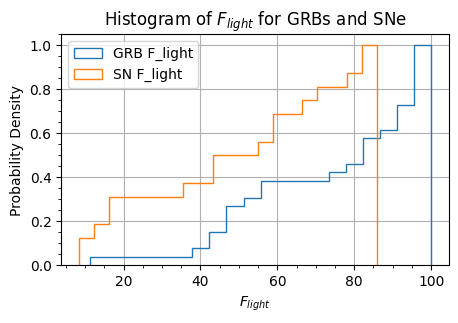

In [ ]:
# Plots the histogram for both datasets
plt.hist(grb_data['F_light'], bins=20, rwidth=0.8, label="GRB F_light", cumulative=True, histtype='step', density=True)
plt.hist(sn_data['F_light'], bins=20, rwidth=0.8, label="SN F_light", cumulative=True, histtype='step', density=True)
plt.xlabel(r"$F_{light}$")
plt.ylabel(r"Probability Density")
plt.title(r"Histogram of $F_{light}$ for GRBs and SNe")
plt.legend()
plt.grid()
plt.show()

**Question 2.2** (2 points): Test the null hypothesis that the $F_{\rm light}$ measurements for SNe and GRBs are drawn from the same parent distribution. Using SciPy, compute both the AD and KS test statistics, along with their corresponding p-values, for the $F_{\rm light}$ samples of SNe and GRBs. Based on these results, is there evidence for a statistically significant difference between the SN and GRB distributions?

*Hint: Look for and read the relevant SciPy documentation.* The challenging part of this question might be finding the right function and how to parse the input/output, which is not the same for both tests.

In [ ]:
from scipy import stats
# performs the different tests and prints the results
AD_test = stats.anderson_ksamp([grb_data['F_light'], sn_data['F_light']])
KS_test = stats.ks_2samp(grb_data['F_light'], sn_data['F_light'])
print(f"Anderson-Darling test statistic: {AD_test.statistic:.3f}, p-value: {AD_test.significance_level:.3f}")
print(f"Kolmogorov-Smirnov test statistic: {KS_test.statistic:.3f}, p-value: {KS_test.pvalue:.3f}")

print('\nThe AD test statistic is relatively high and the p-value is low, which suggests that there is a significant difference between the two distributions. \nThe KS test also shows a significant difference with a low p-value. \nTherefore, we can conclude that the F_light distributions for GRBs and SNe are likely different.')

Anderson-Darling test statistic: 5.231, p-value: 0.003
Kolmogorov-Smirnov test statistic: 0.500, p-value: 0.008

The AD test statistic is relatively high and the p-value is low, which suggests that there is a significant difference between the two distributions. 
The KS test also shows a significant difference with a low p-value. 
Therefore, we can conclude that the F_light distributions for GRBs and SNe are likely different.


Based on the results of the previous question one could infer that SN and GRB occur in different regions of the host galaxy. It seems that the GRBs are found in locations that contain a large fraction of the total galaxy light. However we have to be careful before making general conclusion. Perhaps the observed difference is caused by how the GRB and SN samples were collected. In particular, we want to check that the SNe and GRBs are observed at similar redshifts.  

**Question 2.3** (2 points): Repeat Q2.1 and Q2.2, but for the redshift of the two populations. We are now testing a different null hypothesis, so explicitly write your null hypothesis with a print statement before you do the calculation.

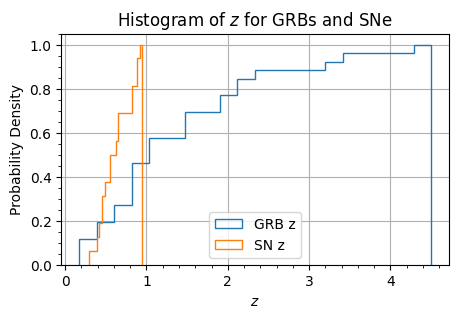

Anderson-Darling test statistic: 7.27310, p-value: 0.00100
Kolmogorov-Smirnov test statistic: 0.69231, p-value: 0.00004


C:\Users\mikov\AppData\Local\Temp\ipykernel_24192\217973896.py:10: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  AD_test = stats.anderson_ksamp([grb_data['z'], sn_data['z']])


In [ ]:
# plots the historgrams now for the z values of both datasets
plt.hist(grb_data['z'], bins=20, rwidth=0.8, label="GRB z", cumulative=True, histtype='step', density=True)
plt.hist(sn_data['z'], bins=20, rwidth=0.8, label="SN z", cumulative=True, histtype='step', density=True)
plt.xlabel(r"$z$")
plt.ylabel(r"Probability Density")
plt.title(r"Histogram of $z$ for GRBs and SNe")
plt.legend()
plt.grid()
plt.show()

AD_test = stats.anderson_ksamp([grb_data['z'], sn_data['z']])
KS_test = stats.ks_2samp(grb_data['z'], sn_data['z'])
print(f"Anderson-Darling test statistic: {AD_test.statistic:.5f}, p-value: {AD_test.significance_level:.5f}")
print(f"Kolmogorov-Smirnov test statistic: {KS_test.statistic:.5f}, p-value: {KS_test.pvalue:.5f}")


Even if you can't solve the previous question, you can simply print the mean or median of the redshift distribution to conclude that the GRBs in our catalog are found at higher redshift compared to SNe.

**Question 2.4** (1 point): Do you think the fact that the GRBs in this sample are, on average, observed at higher redshift than the SNe could bias our conclusion from Q2.2 about the $F_{\rm light}$ distributions? Answer with “yes” or “no”, and motivate your answer.

In [17]:
print('Yes, the redshift shows that GRB\'s are way further away, which could mean that on average they have a much larger luminosity which has an influence on F_light.')

Yes, the redshift shows that GRB's are way further away, which could mean that on average they have a much larger luminosity which has an influence on F_light.


In Q2.2 we have applied the KS and AD test from SciPy as a "black box", so we simply trusted that the used functions gave the correct probability of rejecting the null hypothesis. We can also confirm that they work by applying the test to a sample of simulated SNe and GRBs.

First we merge the $F_{\rm light}$ measurements of the GRBs and SNe into a single population.

In [18]:
# Make a new array that simply contains the data of both populations
f_light_merge = np.concatenate([sn_data['F_light'].value, grb_data['F_light'].value])

Recall that the null hypothesis is that both SNe and GRBs are drawn from the same distribution of the $F_{\rm light}$ observable. If we assume the null hypothesis is true, we can make simulated data of the $F_{\rm light}$ distributions for SNe and GRBs.

This approach is called a Monte Carlo simulation. We can use `np.random.shuffle()` to shuffle the data set.

In [19]:
# Make array of indices
idx = np.arange(len(f_light_merge))

# Let's see how this works: shuffle and print
np.random.shuffle(idx)
print(f'Indices after shuffling:\n{idx}')
np.random.shuffle(idx)
print(f'Indices after shuffling again:\n{idx}')

# Now comes the important trick, the shuffled indices yield simulated SN and GRB subsets:
idx_sn_random = idx[:len(sn_data)]
idx_grb_random = idx[len(sn_data):]
print ('\nF_light for simulated GRBs:', f_light_merge[idx_grb_random])

Indices after shuffling:
[23 10 41  5 32  1 36 31 18 13 29  8 37 35 38 11 17  3 22 26  0 24 25 19
  7 16 15 27 30 21 14 40  2 20 12 28  6 34  4 33  9 39]
Indices after shuffling again:
[17 14 41  8 13 21 29  0  7 26 28  5 30 25 27 23  9 16  1 22 10 34 24  6
 19 40 15 12  2 32  3 33 39 18  4 11 37 31 20 38 35 36]

F_light for simulated GRBs: [ 19.9 100.   37.1  79.4  44.9  58.7  94.   69.1  41.6  86.2  71.4  56.7
   9.3  51.1  83.7  95.3  86.3 100.   44.2  61.  100.   43.9  55.7  75.8
  88.   95.8]


If the p-value calculated with SciPy was correct, then the fraction of Monte Carlo simulations with a test statistic at least as extreme as the observed one should be similar to that p-value.

**Question 2.5** (3 points): Using the approach shown above:

1. Create $10,000$ simulated $F_{\rm light}$ data sets under the null hypothesis.
2. For each simulation, compute the AD statistic for the simulated SN and GRB subsets.
3. Make a histogram of the simulated AD statistics.
4. Compute the fraction of simulations for which the AD statistic is at least as large as the AD statistic of the real observed data.

How does this Monte Carlo estimate compare to the p-value calculated with the SciPy implementation?

C:\Users\mikov\AppData\Local\Temp\ipykernel_24192\3424453419.py:12: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  AD_stats.append(stats.anderson_ksamp([f_light_Grb, f_light_sn]).statistic)
C:\Users\mikov\AppData\Local\Temp\ipykernel_24192\3424453419.py:13: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  p_vals.append(stats.anderson_ksamp([f_light_Grb, f_light_sn]).significance_level)
C:\Users\mikov\AppData\Local\Temp\ipykernel_24192\3424453419.py:12: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  AD_stats.append(stats.anderson_ksamp([f_light_Grb, f_light_sn]).statistic)
C:\Users\mikov\AppData\Local\Temp\ipykernel_24192\3424453419.py:13: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `

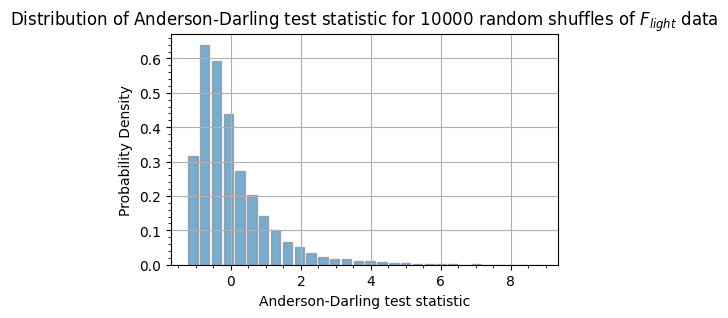

Fraction of random shuffles with Anderson-Darling test statistic greater than or equal to the observed value: 0.290%
Mean p-value from random shuffles: 0.217
p-value from original Anderson-Darling test: 0.003
The mean p-value from the monte carlo simulations is much higher than the observed p-value.


In [ ]:
N = 10000
# Perform the Anderson-Darling test on the original data
AD_test = stats.anderson_ksamp([grb_data['F_light'], sn_data['F_light']])
AD_stats = []
p_vals = []

# Randomly shuffles the data and performs the AD-test for each shuffle, storing the test statistic and p-value for each shuffle in a list
for _ in range(N):
    idx = np.arange(len(f_light_merge))
    np.random.shuffle(idx)
    idx_sn_random = idx[:len(sn_data)]
    idx_grb_random = idx[len(sn_data):]
    f_light_Grb = f_light_merge[idx_grb_random]
    f_light_sn = f_light_merge[idx_sn_random]
    AD_stats.append(stats.anderson_ksamp([f_light_Grb, f_light_sn]).statistic)
    p_vals.append(stats.anderson_ksamp([f_light_Grb, f_light_sn]).significance_level)

# plots the histogram of the AD test statistic for the random shuffles
plt.hist(AD_stats, bins=30, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8)
plt.xlabel(r"Anderson-Darling test statistic")
plt.ylabel(r"Probability Density")
plt.title(r"Distribution of Anderson-Darling test statistic for " + str(N) + r" random shuffles of $F_{light}$ data")
plt.grid()
plt.show()

# calculates the fraction of random shuffles that have an AD test statistic greater than or equal to the observed value
fraction = np.sum(np.array(AD_stats) >= AD_test.statistic) / N
print(f'Fraction of random shuffles with Anderson-Darling test statistic greater than or equal to the observed value: {fraction*100:.3f}%')

# calculates the mean p-value from the random shuffles and compares it to the observed p-value
p_mean = np.mean(p_vals)
print(f'Mean p-value from random shuffles: {p_mean:.3f}')
print(f'p-value from original Anderson-Darling test: {AD_test.significance_level:.3f}')

print('The mean p-value from the monte carlo simulations is much higher than the observed p-value.')

## 3. The first Hubble diagram (10 points)

We will use the data from  [Hubble (1929)](https://doi.org/10.1073/pnas.15.3.168), which established modern cosmology (see this [review](https://doi.org/10.1073/pnas.2536799100) for more background information).

Run the cell below to read the data. The radial velocity is in km/s and the distance is in Mpc.

In [21]:
# Data from Hubble (1929), Table 1

data_str = """
# m_s = photographic magnitude of brightest stars involved.
# r = distance in units of 1e6 parsecs. The first two are Shapley’s values.
# v = measured velocities in km./sec.    N. G. C. 6822, 221, 224 and 5457 are recent determinations by Humason.
# m_t = Holetschek’s visual magnitude as corrected by Hopmann. The first three objects were not measured by Holetschek, and the values of mt represent estimates by the author based upon such data as are available.

name m_s    r 		v_rad  	m_t
SMC  	 ? 		0.032 	+170 	1.5
LMC  	 ? 		0.034 	+290 	0.5
NGC_6822 ? 		0.214 	-130 	9.0
NGC_588  ? 		0.263 	-70  	7.0
NGC_221  ? 		0.275 	-185 	8.8
NGC_224  ? 		0.275 	-220 	5.0
NGC_5457 17.0 	0.45 	+200  	9.9
NGC_4736 17.3 	0.5 	+290   	8.4
NGC_5194 17.3 	0.5 	+270   	7.4
NGC_4449 17.8 	0.63 	+200  	9.5
NGC_4214 18.3 	0.8 	+300   	11.3
NGC_3031 18.5 	0.9 	-8    	8.3
NGC_3627 18.5 	0.9 	+650   	9.1
NGC_4826 18.5 	0.9 	+150   	9.0
NGC_5236 18.5 	0.9 	+500   	10.4
NGC_1068 18.7 	1.0 	+920   	9.1
NGC_5055 19.0 	1.1 	+450   	9.6
NGC_7331 19.0 	1.1 	+500   	10.4
NGC_4258 19.5 	1.4 	+500   	8.7
NGC_4161 20.0 	1.7 	+960   	12.0
NGC_4382 ? 		2.0 	+500 	10.0
NGC_4472 ? 		2.0 	+850 	8.8
NGC_4486 ? 		2.0 	+800 	9.7
NGC_4649 ? 		2.0 	+1090 	9.5
"""

hubble_data = ascii.read(data_str)

**Question 3.1** (1 point): Plot the radial velocity versus distance. This should match the original diagram from 1929, with the exception that the figure by Hubble excludes the Large and Small Magellanic Clouds, while they are included in the table of his paper.

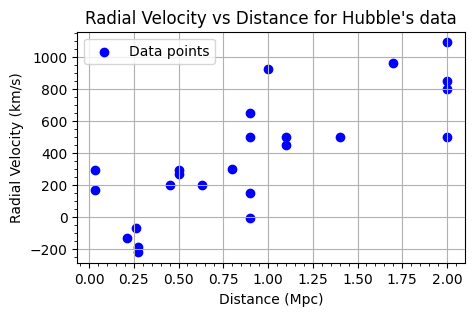

In [ ]:
# plots the data
radial_velocity = hubble_data['v_rad']
distance = hubble_data['r']
plt.scatter(distance, radial_velocity, color='blue', label='Data points')
plt.xlabel(r"Distance (Mpc)")
plt.ylabel(r"Radial Velocity (km/s)")
plt.title(r"Radial Velocity vs Distance for Hubble's data")
plt.grid()
plt.legend()
plt.show()

We now want to quantify whether the apparent correlation is statistically significant.

**Question 3.2** (2 points): Use functions from SciPy to apply the Kendall's $\tau$ test and the Pearson's *r* test to the data in the Hubble diagram from 1929. Report both the test statistic and the p-value for each test.

In [ ]:
# Performs the tau and r tests and compares them
tau_test = stats.kendalltau(distance, radial_velocity)
r_test = stats.pearsonr(distance, radial_velocity)
print(f"Kendall's tau: {tau_test.correlation:.6f}, p-value: {tau_test.pvalue:.6f}")
print(f"Pearson's r: {r_test[0]:.6f}, p-value: {r_test[1]:.6f}")

Kendall's tau: 0.616311, p-value: 0.000045
Pearson's r: 0.791754, p-value: 0.000004


**Question 3.3** (4 points): Kendall's $\tau$ test is a rank-based test: the absolute values of the data points do not matter, only their relative ordering. To develop some intuition about how it works, do the following:

1. Remake the scatter plot of Q3.1. Give the point at index 12 a different color and recreate [this figure from Wikipedia](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient#/media/File:Concordant_Points_Kendall_Correlation.svg). *Hint: `plt.fill_between()` is useful here*.

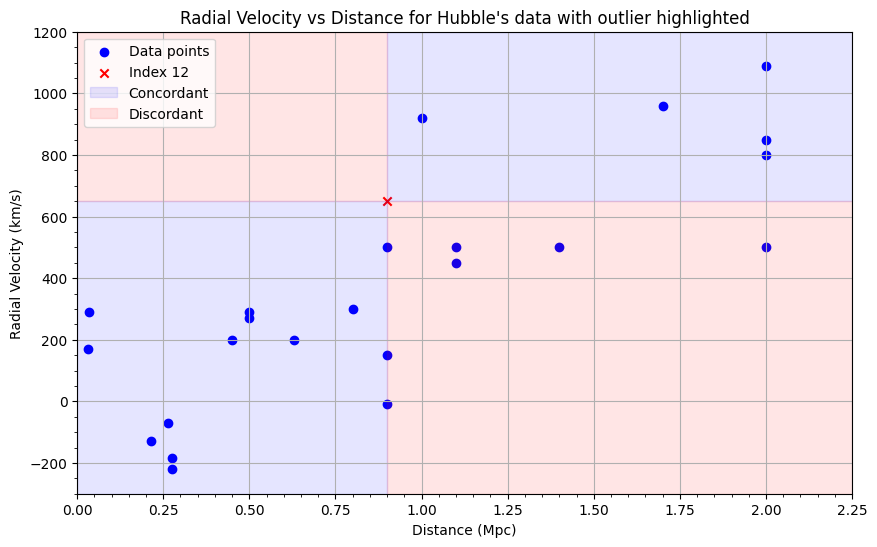

In [ ]:
N_outlier = 12 # Index of the outlier point, not needed as a variable but thought it was nice to change to test other points as well
plt.figure(figsize=(10, 6))

# Scatters the data points
plt.scatter(distance[:N_outlier], radial_velocity[:N_outlier], color='blue', label='Data points')
plt.scatter(distance[N_outlier], radial_velocity[N_outlier], color='red', label='Index 12', marker='x')
plt.scatter(distance[N_outlier+1:], radial_velocity[N_outlier+1:], color='blue')

# Fills the area for the concordant and discordant regions
plt.fill_between([0, distance[N_outlier]], radial_velocity[N_outlier], -300, color='blue', alpha=0.1, label='Concordant')
plt.fill_between([0, distance[N_outlier]], radial_velocity[N_outlier], np.max(radial_velocity)*1.1, color='red', alpha=0.1)
plt.fill_between([distance[N_outlier], 2.5], radial_velocity[N_outlier], np.max(radial_velocity[N_outlier+1:])*1.1, color='blue', alpha=0.1)
plt.fill_between([distance[N_outlier], 2.5], radial_velocity[N_outlier], -300, color='red', alpha=0.1, label='Discordant')

# Adds labels and makes the plot look nicer
plt.xlabel(r"Distance (Mpc)")
plt.ylabel(r"Radial Velocity (km/s)")
plt.title(r"Radial Velocity vs Distance for Hubble's data with outlier highlighted")
plt.xlim(0, 2.25)
plt.ylim(-300, 1200)
plt.grid()
plt.legend()
plt.show()

2. Kendall calls each point in the two shaded regions a *concordant* pair with the highlighted point. Points in the other two regions are called *discordant* pairs. The statistical test involves counting how many pairs fall in each category. Write code that counts how many concordant pairs the point at index 12 has.

In [ ]:
concordant_pairs = 0
discordant_pairs = 0

# calculates the number of concordant and discordant pairs with respect to the outlier
for i in range(len(distance)):
    if i == N_outlier:
        continue
    if (distance[i] < distance[N_outlier] and radial_velocity[i] < radial_velocity[N_outlier]) or (distance[i] > distance[N_outlier] and radial_velocity[i] > radial_velocity[N_outlier]):
        concordant_pairs += 1
    else:
        discordant_pairs += 1

print(f'Number of concordant pairs: {concordant_pairs}')
print(f'Number of discordant pairs: {discordant_pairs}')

Number of concordant pairs: 16
Number of discordant pairs: 7


3. Does the number of concordant pairs depend on which point you choose? Briefly explain.

In [26]:
print('By testing various values of N_outlier, we find that the number of concordant pairs does depend on which point you choose, however it does not differ by a lot.')

By testing various values of N_outlier, we find that the number of concordant pairs does depend on which point you choose, however it does not differ by a lot.


4. Calculate the Kendall's $\tau$ parameter for the entire data set (make sure that each pair of points is counted only once):

$$
\tau = \frac{\text{concordant pairs}-\text{discordant pairs}}{\text{total pairs}}
$$

In [35]:
concordant_pairs = 0
discordant_pairs = 0

# calculates the number of concordant and discordant pairs for each point as the outlier and stores the results in lists
# note that it will never count a pair twice
for N_outlier in range(len(distance)):
    for i in range(N_outlier+1, len(distance)):
        if (distance[i] < distance[N_outlier] and radial_velocity[i] < radial_velocity[N_outlier]) or (distance[i] > distance[N_outlier] and radial_velocity[i] > radial_velocity[N_outlier]):
            concordant_pairs += 1
        elif (distance[i] < distance[N_outlier] and radial_velocity[i] > radial_velocity[N_outlier]) or (distance[i] > distance[N_outlier] and radial_velocity[i] < radial_velocity[N_outlier]):
            discordant_pairs += 1

tau = (concordant_pairs - discordant_pairs) / (concordant_pairs + discordant_pairs)
print(f'Calculated Kendall\'s tau: {tau:.6f}')

Calculated Kendall's tau: 0.644269


**Question 3.4** (2 points): Explain if you prefer the Kendall or Pearson test for this data set. Based on the outcome of your preferred test, would you conclude the correlation between distance and radial velocity is significant? Use the words *"null hypothesis"* in your answer.

In [28]:
print('In my opinion the Kendall test is better for this data set, as it is less sensitive to outliers. \nThe null hypothesis is that there is no correlation between distance and radial velocity, \nhowever as we can see there is a very very small p-value for this test. \nMeaning that there is a correlation, I therefore reject the null hypothesis.')

In my opinion the Kendall test is better for this data set, as it is less sensitive to outliers. 
The null hypothesis is that there is no correlation between distance and radial velocity, 
however as we can see there is a very very small p-value for this test. 
Meaning that there is a correlation, I therefore reject the null hypothesis.


**Question 3.5** (1 point): We now know that Hubble's 1929 distances were too small by a factor of seven. Does this change your conclusion about the *significance* of the correlation? Why (not)?

In [29]:
print('If all distances were smaller by a factor of seven, the correlation would still stand, however it would be much smaller. \nThe order of the distances would not change, only the scale. \nTherefore the significance remains unchanged.')

If all distances were smaller by a factor of seven, the correlation would still stand, however it would be much smaller. 
The order of the distances would not change, only the scale. 
Therefore the significance remains unchanged.


**Final question:** Please provide an estimate of how much time you spent on the entire homework notebook, including time in the tutorial sessions.

In [30]:
print('1hr 15 mins outside of tutorial, 1hr 30 during tutorial')

1hr 15 mins outside of tutorial, 1hr 30 during tutorial
